# Reading data

In [2]:
import pandas as pd
import datetime
data = pd.read_csv("nyc_taxi_trip_duration.csv")

In [3]:
print(data.shape)
print(data.columns)
print(data.dtypes)
data.head()

(729322, 11)
Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')
id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration           int64
dtype: object


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


# Observation

id (non-numeric)- a unique identifier for each trip

vendor_id(numeric) - a code indicating the provider associated with the trip record

pickup_datetime(non-numeric) - date and time when the meter was engaged

dropoff_datetime(non-numeric) - date and time when the meter was disengaged

passenger_count(numeric) - the number of passengers in the vehicle (driver entered value)

pickup_longitude(numeric) - the longitude where the meter was engaged

pickup_latitude(numeric) - the latitude where the meter was engaged

dropoff_longitude(numeric) - the longitude where the meter was disengaged

dropoff_latitude(numeric) - the latitude where the meter was disengaged

store_and_fwd_flag(categorical variable) - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server (Y=store and forward; N=not a store and forward trip)

trip_duration(numeric) - (target) duration of the trip in seconds

In [4]:
#Let's check the count of null values in non numeric

data[["id","store_and_fwd_flag","pickup_datetime","dropoff_datetime"]].count()

id                    729322
store_and_fwd_flag    729322
pickup_datetime       729322
dropoff_datetime      729322
dtype: int64

In [5]:
data.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,7.293220e+05
mean,1.535403,1.662055,-73.973513,40.750919,-73.973422,40.751775,9.522291e+02
std,0.498745,1.312446,0.069754,0.033594,0.069588,0.036037,3.864626e+03
min,1.000000,0.000000,-121.933342,34.712234,-121.933304,32.181141,1.000000e+00
25%,1.000000,1.000000,-73.991859,40.737335,-73.991318,40.735931,3.970000e+02
50%,2.000000,1.000000,-73.981758,40.754070,-73.979759,40.754509,6.630000e+02
75%,2.000000,2.000000,-73.967361,40.768314,-73.963036,40.769741,1.075000e+03
max,2.000000,9.000000,-65.897385,51.881084,-65.897385,43.921028,1.939736e+06


# Univariate analysis

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


# Distribution of non-numeric feature

<AxesSubplot:>

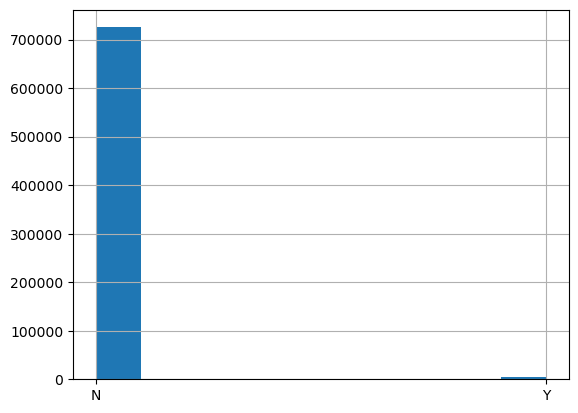

In [7]:
data['store_and_fwd_flag'].hist()

<AxesSubplot:>

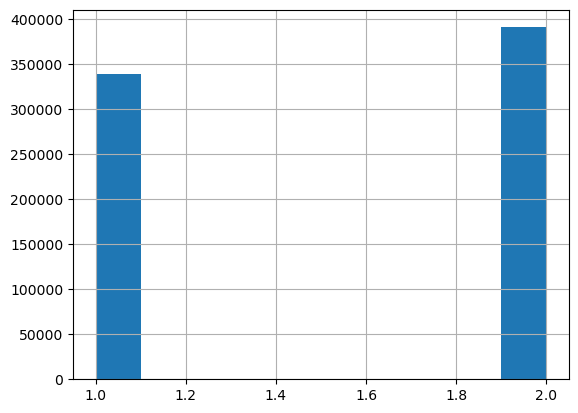

In [8]:
data['vendor_id'].hist()

distribution is good as per expectation none of the categories are dominant

In [9]:
#converting datetime feature to pandas datetime to get more derived features
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"])
data["dropoff_datetime"] = pd.to_datetime(data["dropoff_datetime"])

In [10]:
#1st set of derive features
data["pickup_day"] = data["pickup_datetime"].dt.day_name()
data["dropoff_day"] = data["dropoff_datetime"].dt.day_name()

In [11]:
data['pickup_month'] = data['pickup_datetime'].dt.month
data['pickup_hour'] = data['pickup_datetime'].dt.hour

data['dropoff_month'] = data['dropoff_datetime'].dt.month
data['dropoff_hour'] = data['dropoff_datetime'].dt.hour

<AxesSubplot:xlabel='pickup_month', ylabel='count'>

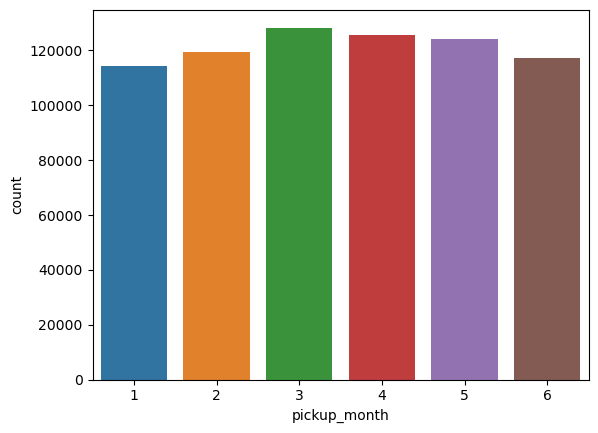

In [12]:
#data['pickup_month'].hist()
sns.countplot(x="pickup_month",data=data)

<AxesSubplot:xlabel='pickup_month', ylabel='count'>

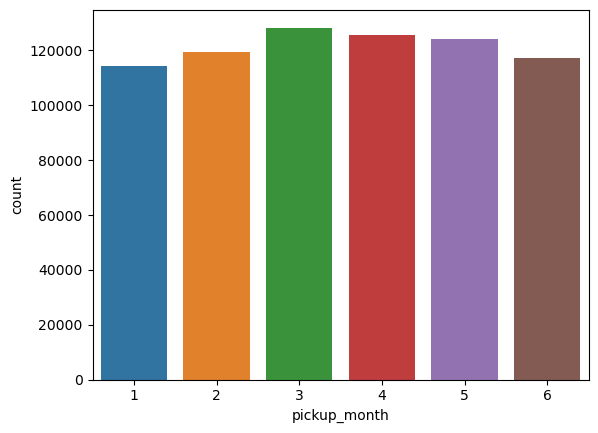

In [13]:
sns.countplot(x="pickup_month",data=data)

<AxesSubplot:xlabel='dropoff_month', ylabel='count'>

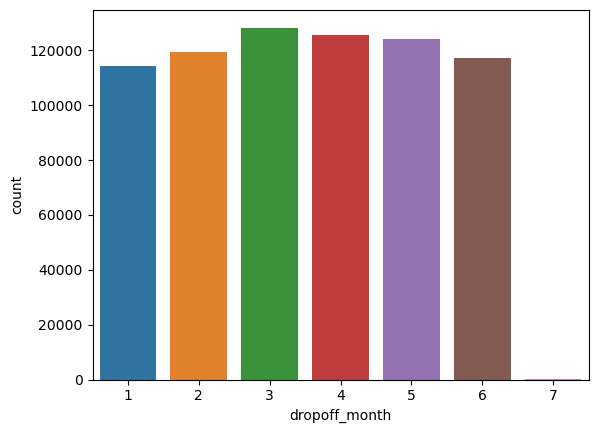

In [14]:
sns.countplot(x="dropoff_month",data=data)

<AxesSubplot:xlabel='pickup_hour', ylabel='count'>

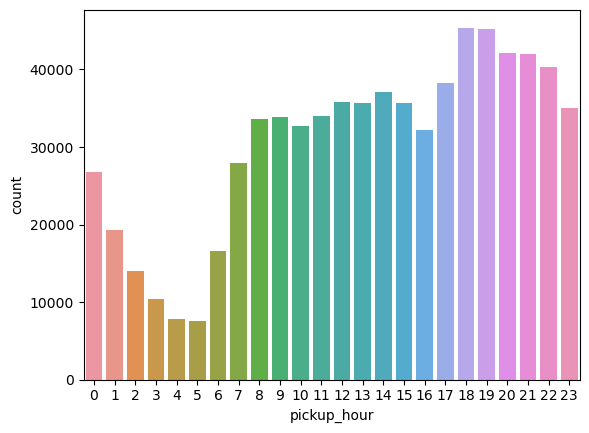

In [15]:
sns.countplot(x="pickup_hour",data=data)

<AxesSubplot:xlabel='dropoff_hour', ylabel='count'>

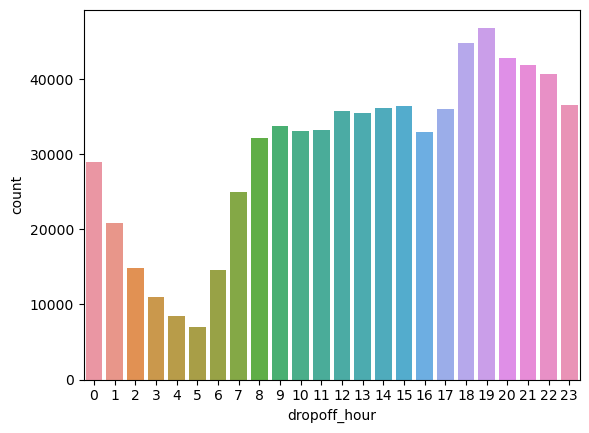

In [16]:
sns.countplot(x="dropoff_hour",data=data)

<AxesSubplot:>

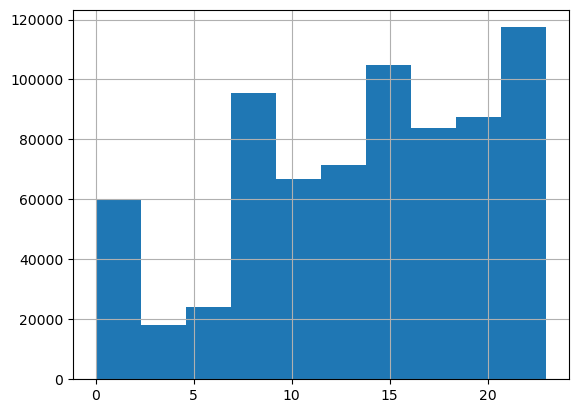

In [17]:
data['pickup_hour'].hist()

<AxesSubplot:>

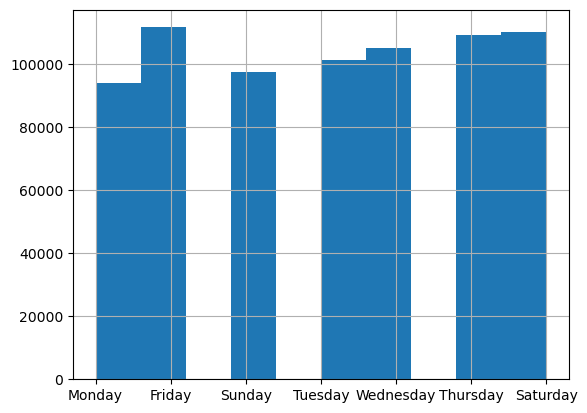

In [18]:
#dsutribution count of the derived feature
data['pickup_day'].hist()

<AxesSubplot:>

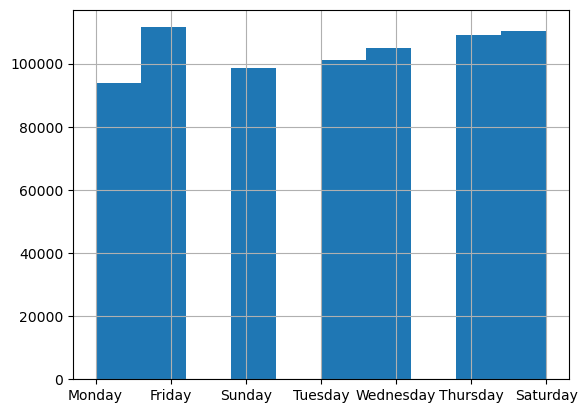

In [19]:
data['dropoff_day'].hist()

In [20]:
def time_category(x):
    if x>=datetime.time(4, 0, 1) and x <=datetime.time(12, 0, 0):
        return 'morning'
    elif x>=datetime.time(12, 0, 1) and x <=datetime.time(16, 0, 0):
        return 'afternoon'
    elif x>=datetime.time(16, 0, 1) and x <=datetime.time(22, 0, 0):
        return 'evening'
    elif x>=datetime.time(22, 0, 1) or x <=datetime.time(4, 0, 0):
        return 'night'
    
data['pickup_time_cat']=data['pickup_datetime'].apply(lambda x :time_category(datetime.datetime.strptime(str(x), "%Y-%m-%d %H:%M:%S").time()) )
data['dropoff_time_cat']=data['dropoff_datetime'].apply(lambda x :time_category(datetime.datetime.strptime(str(x), "%Y-%m-%d %H:%M:%S").time()) )

<AxesSubplot:>

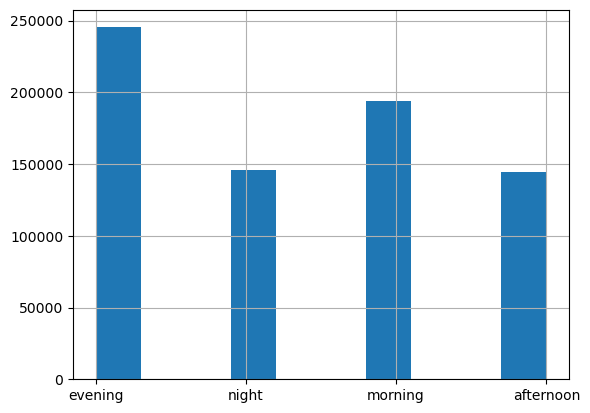

In [21]:
#dsutribution count of the derived feature
data['pickup_time_cat'].hist()

<AxesSubplot:>

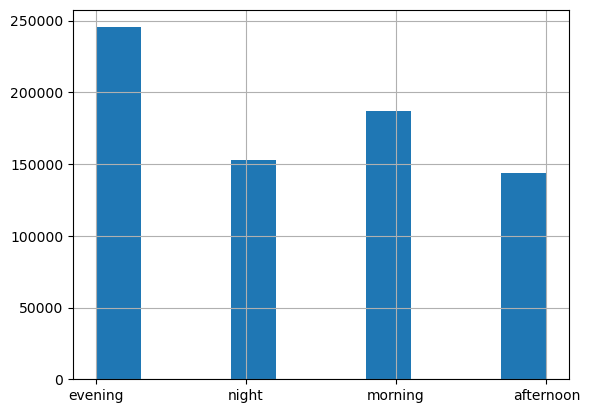

In [22]:
#dsutribution count of the derived feature
data['dropoff_time_cat'].hist()

# Distribution of numeric feature

<AxesSubplot:xlabel='passenger_count', ylabel='Count'>

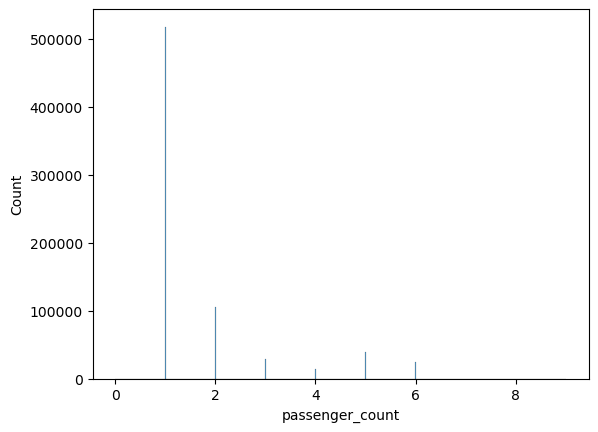

In [23]:
sns.histplot(data['passenger_count'])

In [24]:
data["passenger_count"].value_counts()

1    517415
2    105097
5     38926
3     29692
6     24107
4     14050
0        33
7         1
9         1
Name: passenger_count, dtype: int64

In [25]:
data = data[data["passenger_count"] !=0]

C:\Users\utsav\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='passenger_count', ylabel='Density'>

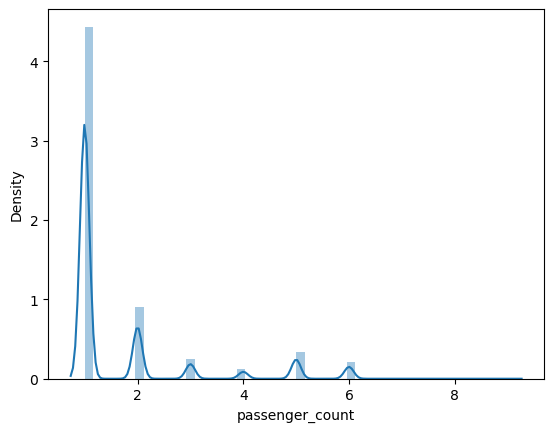

In [26]:
sns.distplot(data['passenger_count'])

C:\Users\utsav\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='pickup_latitude', ylabel='Density'>

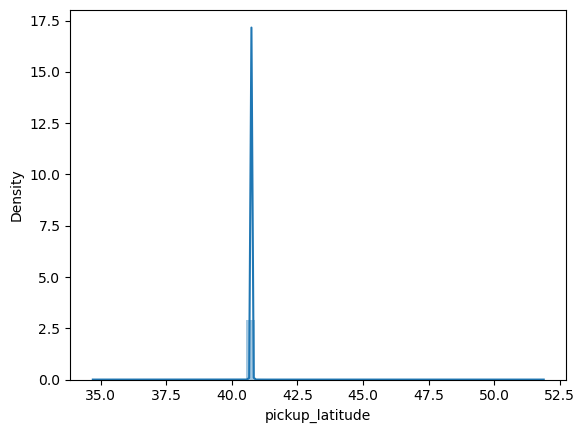

In [27]:
sns.distplot(data['pickup_latitude'])

C:\Users\utsav\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='pickup_longitude', ylabel='Density'>

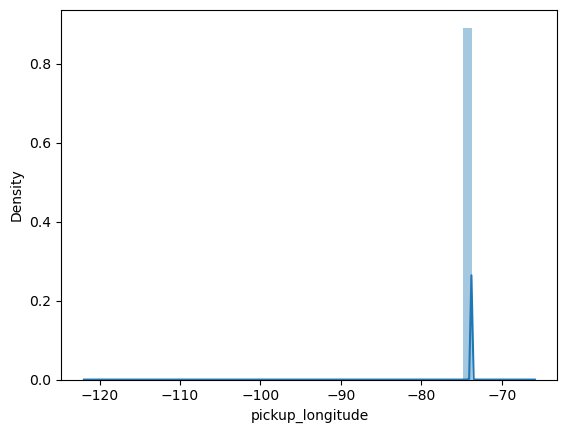

In [28]:
sns.distplot(data['pickup_longitude'])

C:\Users\utsav\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='dropoff_latitude', ylabel='Density'>

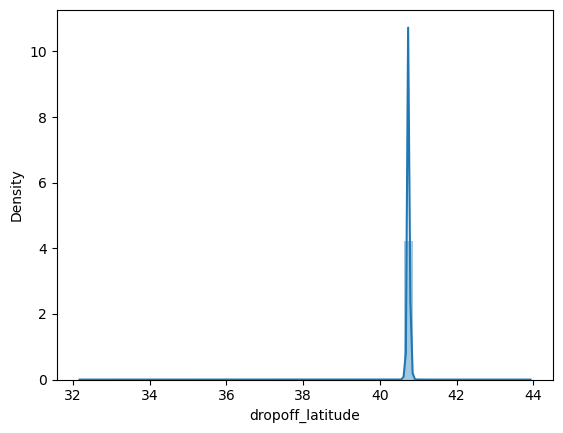

In [29]:
sns.distplot(data['dropoff_latitude'])

C:\Users\utsav\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


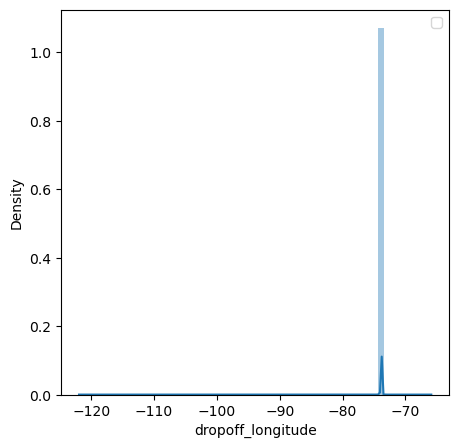

In [30]:
fig = plt.figure(figsize=(5,5))
sns.distplot(data['dropoff_longitude'],kde=True,bins=60)
plt.legend()

In [31]:
from geopy.distance import great_circle
def distance_from_lat_long(pickup_lat,pickup_long,dropoff_lat,dropoff_long):
 
     start_coordinates=(pickup_lat,pickup_long)
     stop_coordinates=(dropoff_lat,dropoff_long)
 
     return great_circle(start_coordinates,stop_coordinates).km

In [32]:
data['total_dis'] = data.apply(lambda x: distance_from_lat_long(x['pickup_latitude'],x['pickup_longitude'],x['dropoff_latitude'],x['dropoff_longitude'] ), axis=1)

In [33]:
data['total_dis'].value_counts()

0.000000    2894
0.000424      20
0.000424      19
0.000424      16
0.000424      11
            ... 
2.929161       1
0.977650       1
0.925223       1
4.112012       1
5.945846       1
Name: total_dis, Length: 726219, dtype: int64

In [34]:
#dropping of the distnace which are 0
#data = data[data["total_dis"]==0.000000]

# Analysing Target variable

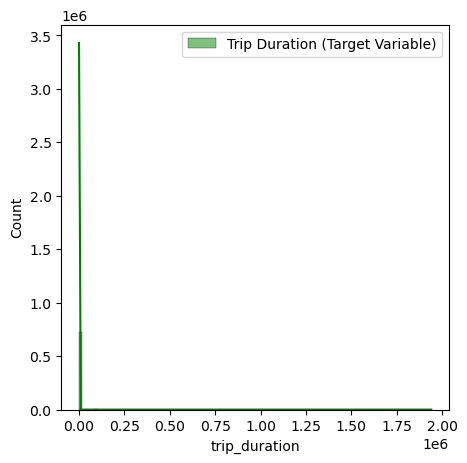

In [35]:
fig = plt.figure(figsize=(5,5))
sns.histplot(data.trip_duration,color='green',label='Trip Duration (Target Variable)',kde=True,bins=120)
plt.legend()

C:\Users\utsav\anaconda3\lib\site-packages\seaborn\_core.py:1319: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


<AxesSubplot:ylabel='trip_duration'>

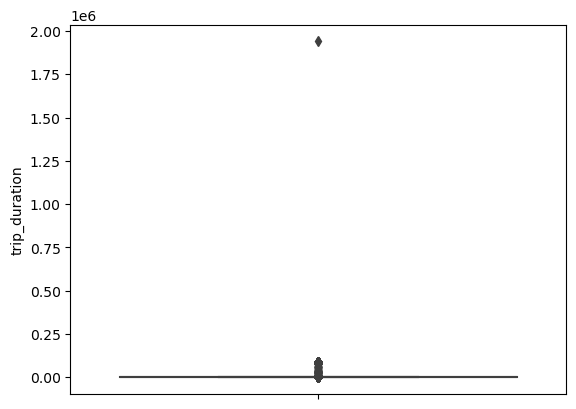

In [36]:
#perform boxplot to find the range of outlier
sns.boxplot(x=None,y=data['trip_duration'],orient='h')

In [37]:
data["trip_duration"].nlargest(20)

21813     1939736
259437      86391
119185      86387
177225      86378
496391      86377
90557       86369
673847      86369
163178      86367
179065      86365
248675      86364
680575      86363
273385      86362
403788      86362
589429      86361
624763      86361
162421      86360
612104      86358
141117      86357
620826      86357
440893      86356
Name: trip_duration, dtype: int64

In [38]:
data=data[data.trip_duration!=data.trip_duration.max()]

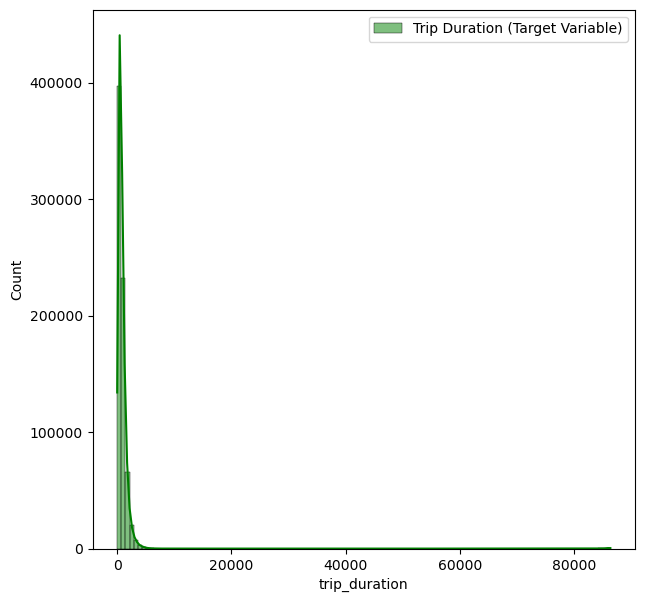

In [39]:
fig = plt.figure(figsize=(7,7))
sns.histplot(data.trip_duration,color='green',label='Trip Duration (Target Variable)',kde=True,bins=120)
plt.legend()

In [40]:
import numpy as np
bins=np.array([0,1800,3600,5400,7200,90000])
data['duration_cat']=pd.cut(data.trip_duration,bins,labels=["less 5", "5-10", "10-15","15-20"," greater 20"])

In [41]:
data['duration_cat'].value_counts()

less 5         672858
5-10            50369
10-15            4574
 greater 20      1091
15-20             396
Name: duration_cat, dtype: int64

<AxesSubplot:>

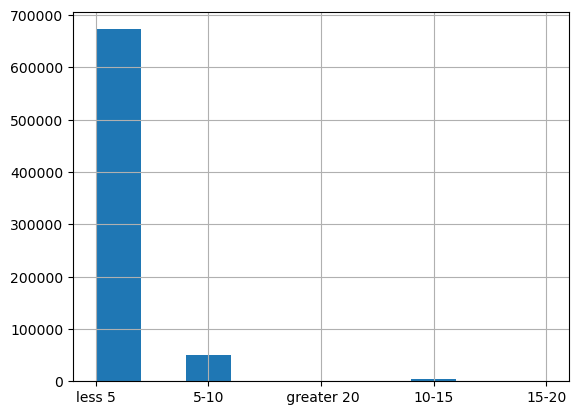

In [42]:
data['duration_cat'].hist()

# Bi-variate analysis

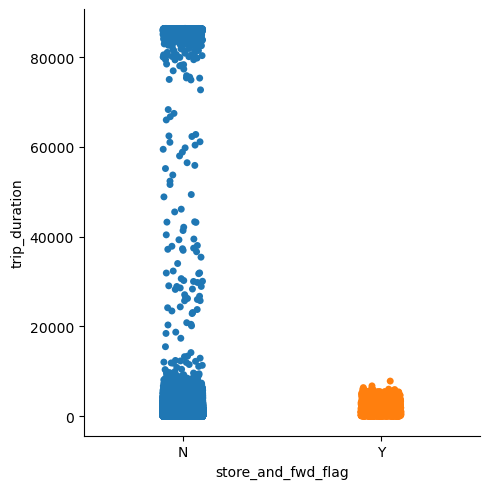

In [43]:
#plt.title("Bi-Variate analysis of duration vs store flag")
sns.catplot(x="store_and_fwd_flag", y="trip_duration",kind="strip",data=data)

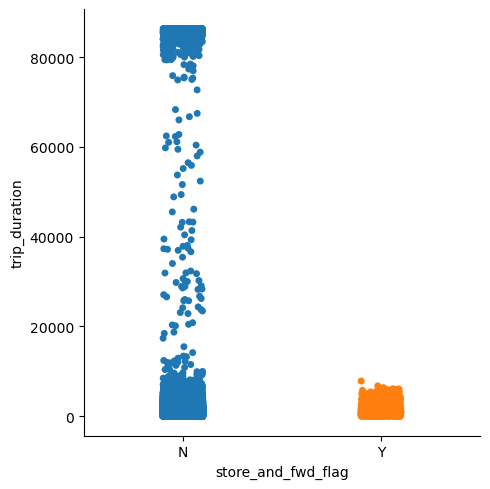

In [44]:
sns.catplot(x="store_and_fwd_flag", y="trip_duration",kind="strip",data=data)

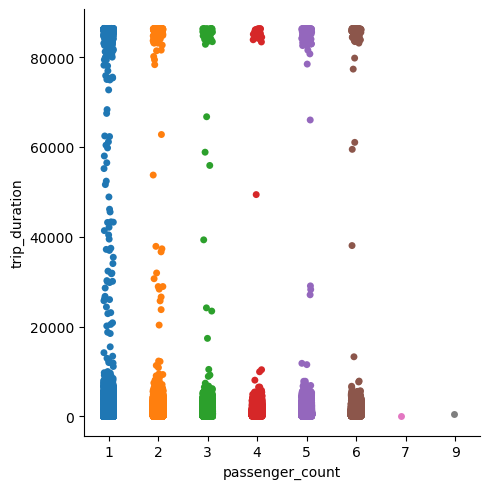

In [45]:
sns.catplot(x="passenger_count", y="trip_duration",kind="strip",data=data)

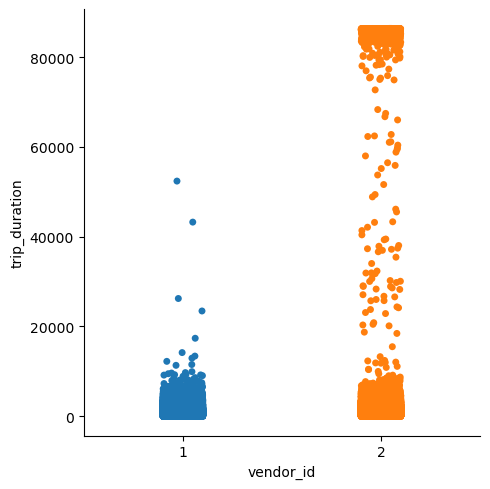

In [46]:
sns.catplot(x="vendor_id", y="trip_duration",kind="strip",data=data)

<AxesSubplot:xlabel='pickup_hour', ylabel='trip_duration'>

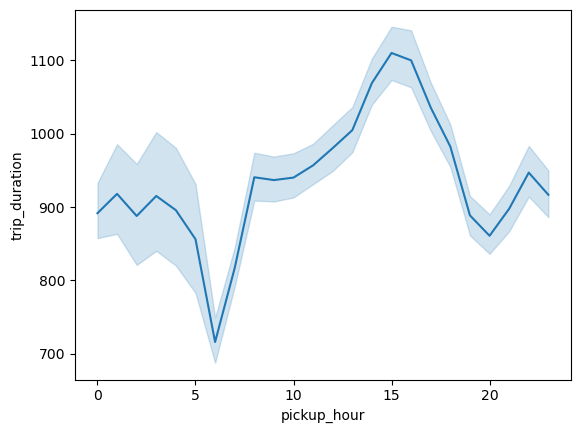

In [47]:
sns.lineplot(x="pickup_hour", y="trip_duration",data=data)

<AxesSubplot:xlabel='pickup_hour', ylabel='total_dis'>

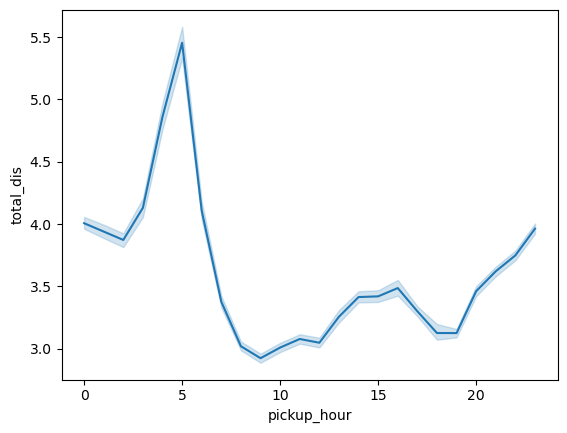

In [48]:
sns.lineplot(x="pickup_hour", y="total_dis",data=data)

<AxesSubplot:xlabel='pickup_month', ylabel='trip_duration'>

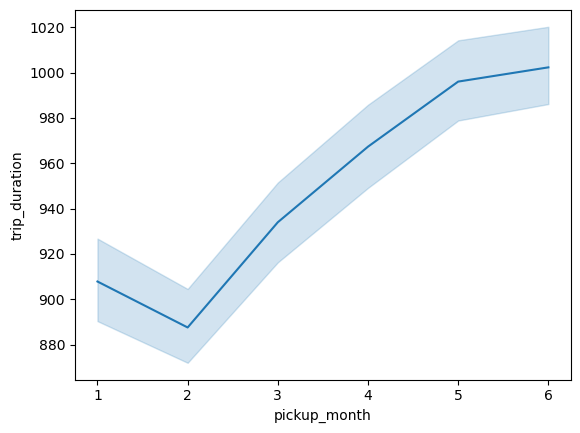

In [49]:
sns.lineplot(x="pickup_month", y="trip_duration",data=data)

<AxesSubplot:xlabel='pickup_month', ylabel='total_dis'>

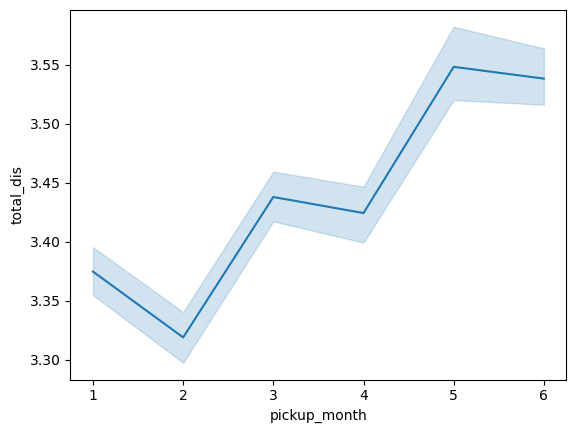

In [50]:
sns.lineplot(x="pickup_month", y="total_dis",data=data)

<AxesSubplot:xlabel='pickup_day', ylabel='trip_duration'>

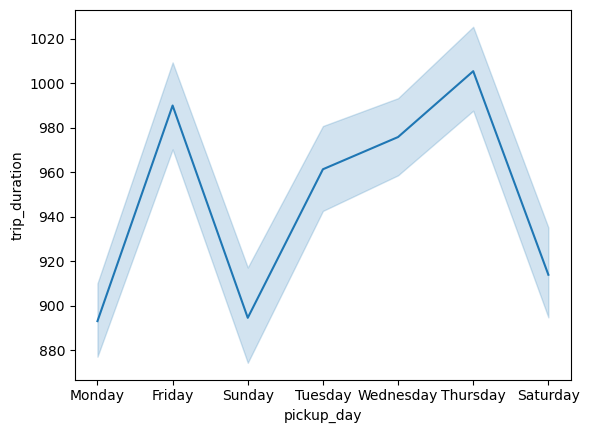

In [51]:
sns.lineplot(x="pickup_day", y="trip_duration",data=data)

<AxesSubplot:xlabel='pickup_day', ylabel='total_dis'>

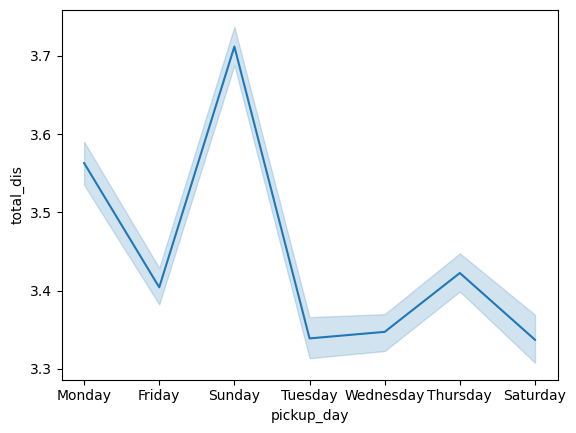

In [52]:
sns.lineplot(x="pickup_day", y="total_dis",data=data)

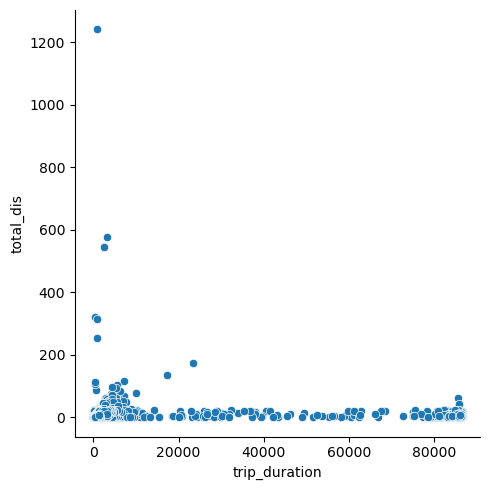

In [53]:
sns.relplot(y="total_dis", x="trip_duration",data=data)

# Conclusion

there is no column that have null values

For longer trip store flag variable has not been stored

Majority of the passenger count are 1 followed by 2,5,3,6,4

Friday has the hightest pickoff while Monday has the lowest pickoff

Total distance covered maximum on Sunday

longer distance covered by passenger count 1,2,5,7

Trip duration are max at 17-19 hour

Total disatnce has been covered maximum in the fifth hour

Maximum trip duration has been happened in June

Max distance has been covered in June

Trip duration is the target variable which is still rightly skewed after removing the outlier

Trip duration has been split into four parts ("less 5", "5-10", "10-15","15-20"," greater 20"),were majority of trip duration are less than 5hours


In [55]:
#dropping off the datetime column as we are using feature variable derived from that column
#Also dropping vendor id as it doesn't make any sense

data_trans = data[['id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_day', 'dropoff_day', 'pickup_month',
       'pickup_hour', 'dropoff_month', 'dropoff_hour', 'pickup_time_cat',
       'dropoff_time_cat', 'total_dis', 'duration_cat']]

In [58]:
#dropping off the passenger count 7 & 9 which are very less

data_trans = data_trans[data_trans["passenger_count"]!=7]
data_trans = data_trans[data_trans["passenger_count"]!=9]

In [59]:
mean_dist = data_trans['total_dis'].mean() 
data_trans.loc[data_trans['total_dis']==0.000000,'total_dis']=mean_dist

In [60]:
print(mean_dist)

3.4411996331747825


# Transforming categorical values

In [61]:
data_trans.columns

Index(['id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_day', 'dropoff_day', 'pickup_month',
       'pickup_hour', 'dropoff_month', 'dropoff_hour', 'pickup_time_cat',
       'dropoff_time_cat', 'total_dis', 'duration_cat'],
      dtype='object')

In [63]:
data_trans.head()

,id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_day,dropoff_day,pickup_month,pickup_hour,dropoff_month,dropoff_hour,pickup_time_cat,dropoff_time_cat,total_dis,duration_cat
0,id1080784,1,-73.953918,40.778873,-73.963875,40.771164,N,400,Monday,Monday,2,16,2,16,evening,evening,1.199074,less 5
1,id0889885,2,-73.988312,40.731743,-73.994751,40.694931,N,1100,Friday,Friday,3,23,3,23,night,night,4.129117,less 5
2,id0857912,2,-73.997314,40.721458,-73.948029,40.774918,N,1635,Sunday,Sunday,2,17,2,18,evening,evening,7.250763,less 5
3,id3744273,6,-73.961670,40.759720,-73.956779,40.780628,N,1141,Tuesday,Tuesday,1,9,1,10,morning,morning,2.361101,less 5
4,id0232939,1,-74.017120,40.708469,-73.988182,40.740631,N,848,Wednesday,Wednesday,2,6,2,6,morning,morning,4.328540,less 5


In [67]:
data_trans["duration_cat"].unique()

['less 5', '5-10', ' greater 20', '10-15', '15-20']
Categories (5, object): ['less 5' < '5-10' < '10-15' < '15-20' < ' greater 20']

In [68]:
data_trans["store_and_fwd_flag"]=data_trans["store_and_fwd_flag"].replace({'N':0,'Y':1})

data_trans["pickup_day"]=data_trans["pickup_day"].replace({'Monday':0, 
                                                           'Friday':1, 
                                                           'Sunday':2, 
                                                           'Tuesday':3, 
                                                           'Wednesday':4, 
                                                           'Thursday':5,
                                                           'Saturday':6})

data_trans["dropoff_day"]=data_trans["dropoff_day"].replace({'Monday':0, 
                                                           'Friday':1, 
                                                           'Sunday':2, 
                                                           'Tuesday':3, 
                                                           'Wednesday':4, 
                                                           'Thursday':5,
                                                           'Saturday':6})

data_trans["pickup_time_cat"]=data_trans["pickup_time_cat"].replace({'evening':0, 
                                                                     'night':1,
                                                                     'morning':2, 
                                                                     'afternoon':3})

data_trans["dropoff_time_cat"]=data_trans["dropoff_time_cat"].replace({'evening':0, 
                                                                     'night':1,
                                                                     'morning':2, 
                                                                     'afternoon':3})

data_trans['duration_cat']=data_trans["duration_cat"].replace({'less 5':0, 
                                                               '5-10':1, 
                                                               ' greater 20':2,
                                                               '10-15':3, 
                                                               '15-20':4})



# Splitting Train and Test data

In [71]:
#data_trans.head()
from sklearn.model_selection import train_test_split
y= data_trans["trip_duration"]
X=data_trans.drop(columns=["id","trip_duration"])
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, shuffle = True, random_state = 2021)

# Data Processing 

In [82]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
def data_preproc(sample_data,numeric_col,cat_col):
    le = LabelEncoder()
    ss = StandardScaler()
    sample_data[numeric_col] = ss.fit_transform(sample_data[numeric_col])
    for col in cat_col:
        sample_data[col] = le.fit_transform(sample_data[col])
    return sample_data    

In [83]:
#X_train.columns
numeric_col = [ 'pickup_longitude', 'pickup_latitude',
'dropoff_longitude', 'dropoff_latitude',
'total_dis']
cat_col = ['passenger_count', 'store_and_fwd_flag',
       'pickup_day', 'dropoff_day', 'pickup_month', 'pickup_hour',
       'dropoff_month', 'dropoff_hour', 'pickup_time_cat', 'dropoff_time_cat',
       'duration_cat']

X_train_prepoc=data_preproc(X_train,numeric_col,cat_col)
X_test_prepoc=data_preproc(X_test,numeric_col,cat_col)

# Model training 

In [86]:
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_absolute_error as mae
lr = LR()

# Fitting the model
lr.fit(X_train_prepoc, y_train)

LinearRegression()

In [88]:
train_predict = lr.predict(X_train_prepoc)
k = mae(train_predict, y_train)
print('Training Mean Absolute Error', k )

Training Mean Absolute Error 595.4469409376479


In [91]:
#len(train_predict)
test_predict = lr.predict(X_test_prepoc)
k_test = mae(test_predict, y_test)
print('Test Mean Absolute Error', k_test )

Test Mean Absolute Error 584.2634482568312


In [102]:
lr.coef_

array([ 3.13305914e+01, -1.41953448e+02,  5.11984539e+01, -3.93538476e+00,
        2.27793549e+01, -2.11909834e+02,  5.13330796e+01, -5.08778672e+01,
       -1.29679676e+04, -3.85367039e-01,  1.29605576e+04, -1.88970543e+00,
       -1.46222684e+02,  1.32564080e+02, -1.22541214e+02,  3.39761262e+03])

# Plotting feature coefficient of Linear regression

Text(0.5, 1.0, 'Coefficient plot')

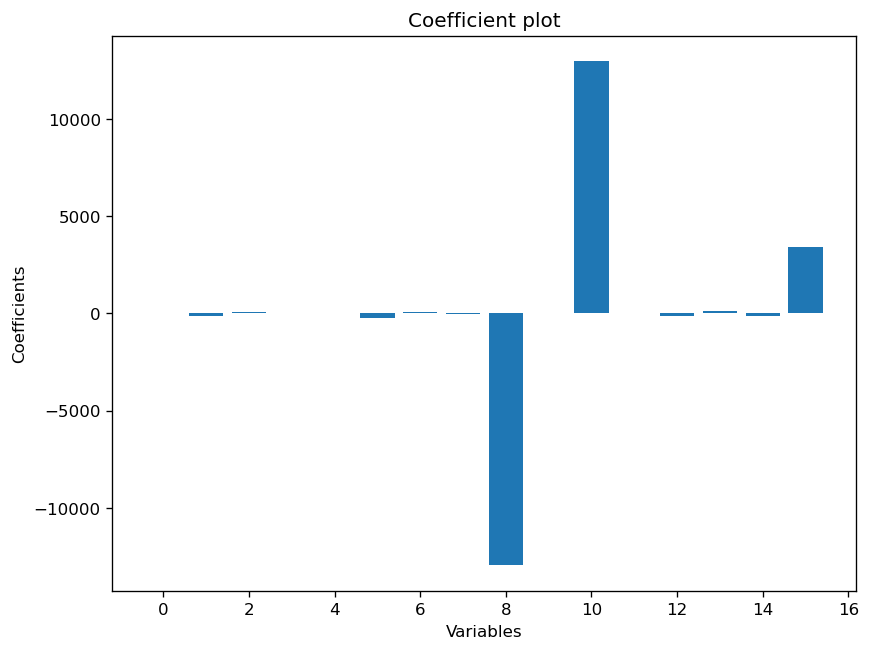

In [105]:
plt.figure(figsize=(8, 6), dpi=120, facecolor='w', edgecolor='b')
x = range(len(X_train_prepoc.columns))
y = lr.coef_
plt.bar( x, y )
plt.xlabel( "Variables")
plt.ylabel('Coefficients')
plt.title('Coefficient plot')

# Calculating Residual

In [106]:
# Arranging and calculating the Residuals
residuals = pd.DataFrame({
    'fitted values' : y_test,
    'predicted values' : test_predict,
})

residuals['residuals'] = residuals['fitted values'] - residuals['predicted values']
residuals.head()

,fitted values,predicted values,residuals
147981,3973,9402.352192,-5429.352192
377690,365,739.860215,-374.860215
530746,137,745.817971,-608.817971
553986,3793,10725.456955,-6932.456955
488265,545,599.395271,-54.395271


# Plotting residual curve

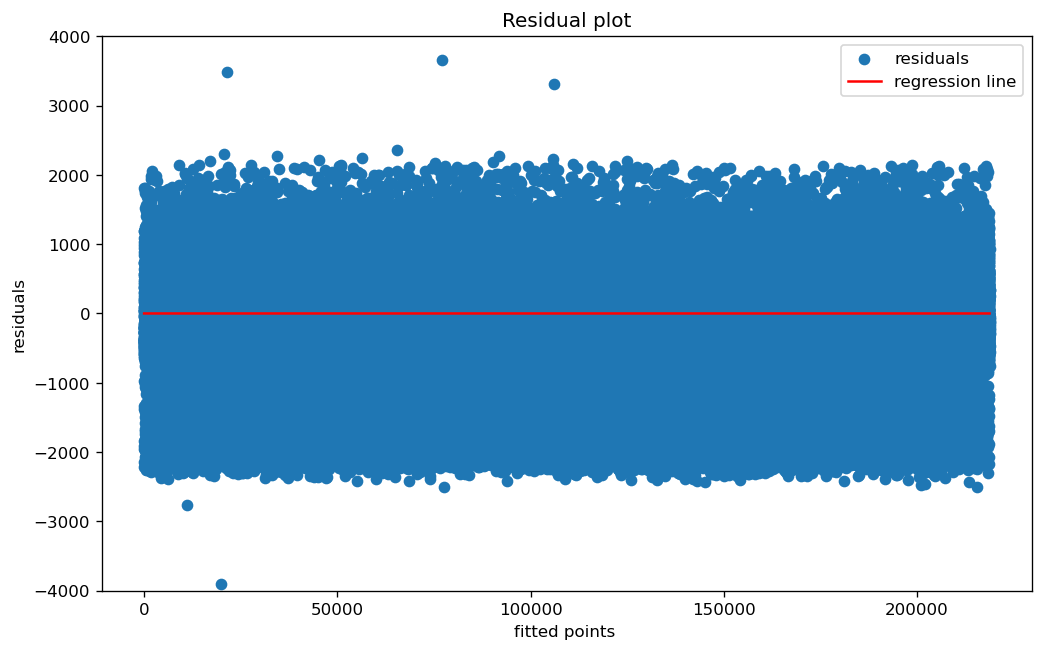

In [109]:
plt.figure(figsize=(10, 6), dpi=120, facecolor='w', edgecolor='b')
f = range(0,218786)
k = [0 for i in range(0,218786)]
plt.scatter( f, residuals.residuals[:], label = 'residuals')
plt.plot( f, k , color = 'red', label = 'regression line' )
plt.xlabel('fitted points ')
plt.ylabel('residuals')
plt.title('Residual plot')
plt.ylim(-4000, 4000)
plt.legend()